## Sección 1

### Importando Librerías

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os

### Leyendo archivos en formato csv de Películas

In [3]:
path = kagglehub.dataset_download('tmdb/tmdb-movie-metadata')

df_movies  = pd.read_csv(os.path.join(path, 'tmdb_5000_movies.csv'))
df_credits = pd.read_csv(os.path.join(path, 'tmdb_5000_credits.csv'))

print(df_movies.shape)
print(df_credits.shape)

(4803, 20)
(4803, 4)


## Sección 2

Seccion 2 — Merge de los dos datasets
df_movies tiene columna id y df_credits tiene columna movie_id. Son la misma clave. Despues del merge aparecen columnas duplicadas (title_x, title_y, movie_id) que hay que limpiar.

Pista: usa pd.merge(..., left_on='id', right_on='movie_id') y luego drop() y rename().

### Mergeando datasets, quitando columnas duplicadas y renombrando columna

In [4]:
df = pd.merge(df_movies, df_credits, left_on='id', right_on='movie_id').drop(['title_y', 'movie_id'], axis=1).rename(columns={'title_x': 'title'})

In [5]:
# df = df_movies.merge(df_credits, left_on='id', right_on='movie_id', how='inner')

# df = df.drop(columns=['movie_id', 'title_y'], errors='ignore')
# df = df.rename(columns={'title_x': 'title'})

In [6]:
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## Sección 3

Seccion 3 — Parseo de columnas JSON
Las columnas genres, cast y crew no son listas reales, son strings con formato JSON. Antes de usarlas hay que parsearlas con json.loads().

Tienes que implementar tres funciones:

parse_json_col(val) — convierte el string a lista de dicts. Usa try/except para manejar valores nulos.
extract_names(val, key, limit) — llama a la anterior y extrae el valor de key de cada dict.
get_director(crew_str) — recorre el crew buscando el dict donde job == 'Director' y devuelve su name.
Luego aplica estas funciones para crear: genres_list, main_genre (primer elemento de la lista), director, y release_year (desde release_date con .dt.year).

Pista: usa .apply() para aplicar una funcion a toda una columna. Para el año: convierte primero con pd.to_datetime().

### Parseo de columnas JSON

#### Función parse_json_col(val) — convierte el string a lista de dicts. Usa try/except para manejar valores nulos.

**Pruebo las funciones con datos de prueba que he sacado del DataFrame y más abajo uso estas funciones para hacer el ejercicio**

In [7]:
import json

val = '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}]'

def parse_json_col(val):
    try:
        return json.loads(val)
    except (ValueError, TypeError):
        return []

print(parse_json_col(val))

[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}]


#### Función extract_names(val, key, limit) — llama a la anterior y extrae el valor de key de cada dict.

In [8]:
def extract_names(val, key='name', limit=None):
    items = parse_json_col(val)
    names = [d[key] for d in items if key in d]
    return names[:limit] if limit else names

print(extract_names(val, key='name', limit=None))

['Action', 'Adventure']


#### Función get_director(crew_str) — recorre el crew buscando el dict donde job == 'Director' y devuelve su name.

In [9]:

crew_str =  '''[{"credit_id": "54805967c3a36829b5002c41", "department": "Sound", "gender": 2, "id": 153, "job": "Original Music Composer", "name": "Thomas Newman"}, 
              {"credit_id": "54805967c3a36829b5002c41", "department": "Sound", "gender": 2, "id": 154, "job": "Director", "name": "Juanma"}]'''

def get_director(crew_str):
    for member in parse_json_col(crew_str):
        if member.get("job") == "Director":
            return member.get("name", np.nan)
    return np.nan

print(get_director(crew_str))

Juanma


#### Luego aplica estas funciones para crear: genres_list, main_genre (primer elemento de la lista), director, y release_year (desde release_date con .dt.year).

In [10]:
df['genres_list'] = df['genres'].apply(extract_names)
df['main_genre'] = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')
df['director'] = df['crew'].apply(get_director)

# Convertir a datetime primero
#df['release_date'] = pd.to_datetime(df['release_date'])
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
# Obtener el año
df['release_year'] = df['release_date'].dt.year

In [11]:
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,tagline,title,vote_average,vote_count,cast,crew,genres_list,main_genre,director,release_year
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...","[Action, Adventure, Fantasy, Science Fiction]",Action,James Cameron,2009.0
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...","[Adventure, Fantasy, Action]",Adventure,Gore Verbinski,2007.0
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...","[Action, Adventure, Crime]",Action,Sam Mendes,2015.0


#### La columna *release_year* se queda como float

In [12]:
df['release_year'].dtype

dtype('float64')

## Sección 4

Seccion 4 — Limpieza de datos
budget=0 y revenue=0 no son ceros reales, son valores faltantes que el dataset codifica asi. Hay que filtrarlos junto con peliculas no estrenadas o sin director conocido.

Pista: encadena las condiciones con & dentro de un solo filtro booleano. Recuerda hacer .copy() al final para evitar el SettingWithCopyWarning.

### Limpieza de datos

In [13]:
df = df[
    (df['budget']  > 100_000) &
    (df['revenue'] > 100_000) &
    (df['status']  == 'Released') &
    (df['runtime'] > 0) &
    (df['director'].notna())
].copy()

## Sección 5

Seccion 5 — Analisis exploratorio
El objetivo es entender la forma de las distribuciones antes de modelar. Tres graficos: histogramas de revenue y budget, revenue mediano por genero, y scatter de budget vs revenue.

Pista: para el grafico de generos, usa .groupby('main_genre')['revenue'].median().sort_values() y luego .plot(kind='barh').

### Análisis exploratorio

In [14]:
import matplotlib.pyplot as plt

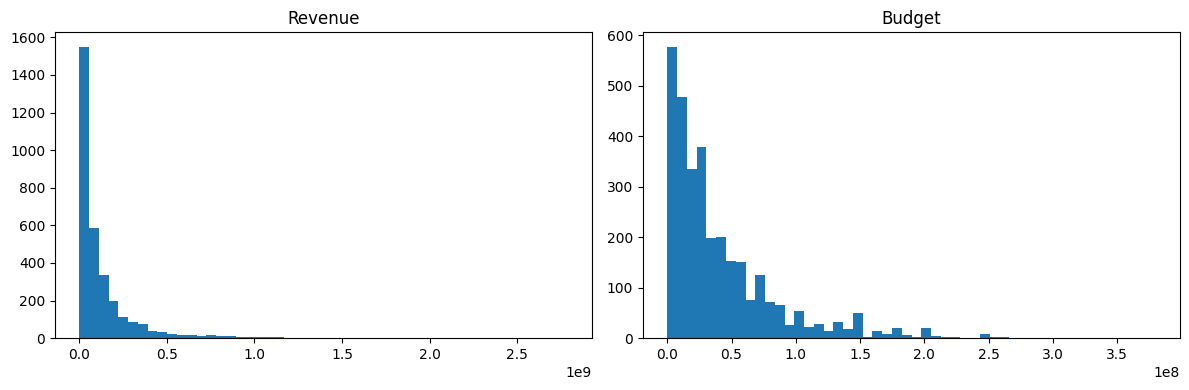

In [15]:
# Histogramas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['revenue'], bins=50)
axes[0].set_title('Revenue')
axes[1].hist(df['budget'], bins=50)
axes[1].set_title('Budget')
plt.tight_layout()
plt.show()

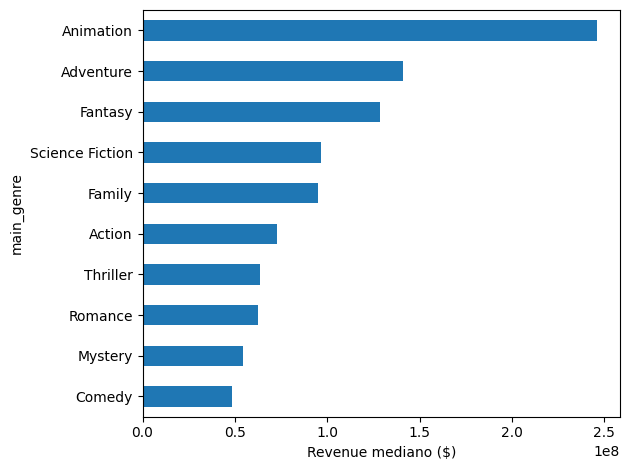

In [16]:
# Revenue mediano por genero
df.groupby('main_genre')['revenue'].median().sort_values(ascending=False).head(10).plot(kind='barh')
plt.xlabel('Revenue mediano ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

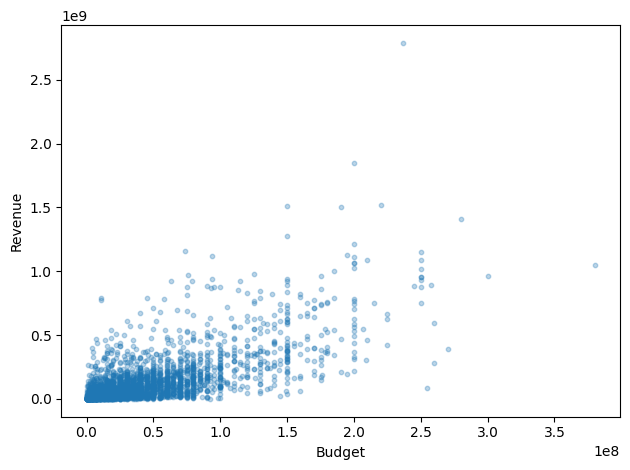

In [17]:
# Scatter
plt.scatter(df['budget'], df['revenue'], alpha=0.3, s=10)
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

## Sección 6

Seccion 6 — Transformacion logaritmica
revenue y budget tienen distribuciones con cola muy larga (unos pocos blockbusters distorsionan todo). La transformacion log comprime esa escala y hace la relacion mas lineal, que es exactamente lo que asume la regresion lineal.

Usa np.log1p() en lugar de np.log() porque es seguro cuando hay valores en cero.

Para la matriz de correlacion usa sns.heatmap() con annot=True sobre el resultado de .corr().

Pista: en una relacion log-log, el coeficiente de regresion se interpreta como elasticidad: "por cada 1% de aumento en X, Y cambia un β%".

### Transformación logaritmica

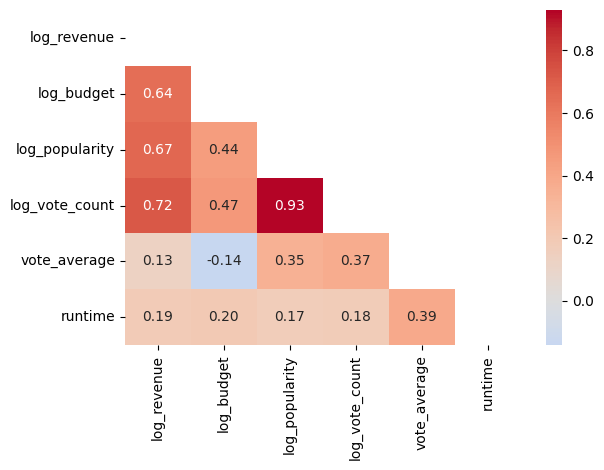

In [18]:
import seaborn as sns

df['log_revenue']    = np.log1p(df['revenue'])
df['log_budget']     = np.log1p(df['budget'])
df['log_popularity'] = np.log1p(df['popularity'])
df['log_vote_count'] = np.log1p(df['vote_count'])

vars_corr = ['log_revenue', 'log_budget', 'log_popularity',
             'log_vote_count', 'vote_average', 'runtime']

mask = np.triu(np.ones(len(vars_corr), dtype=bool))
sns.heatmap(df[vars_corr].corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

## Sección 7

Seccion 7 — Regresion lineal simple

El modelo mas basico: una sola variable de entrada. Sirve como punto de referencia (baseline) para comparar con los modelos mas complejos despues.

El flujo es siempre el mismo: split → fit → predict → evaluar con R² y RMSE.

Pista: r2_score(y_test, y_pred) y np.sqrt(mean_squared_error(y_test, y_pred)). Para la linea de regresion en el scatter, genera puntos con np.linspace y aplica manualmente intercept_ + coef_[0] * x.

### Regresión lineal simple

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

R²:   0.4062
RMSE: 1.3041
β₁:   0.8062


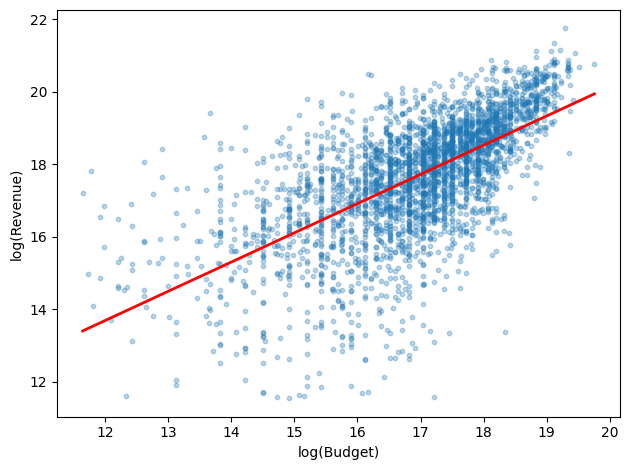

In [20]:
X = df[['log_budget']]
y = df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression().fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f'R²:   {r2_score(y_test, y_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'β₁:   {modelo.coef_[0]:.4f}')

# Scatter con linea
x_line = np.linspace(df['log_budget'].min(), df['log_budget'].max(), 100)
plt.scatter(df['log_budget'], df['log_revenue'], alpha=0.3, s=10)
plt.plot(x_line, modelo.intercept_ + modelo.coef_[0] * x_line, color='red', lw=2)
plt.xlabel('log(Budget)')
plt.ylabel('log(Revenue)')
plt.tight_layout()
plt.show()

## Sección 8

Seccion 8 — Diagnostico de residuos

R² alto no garantiza que el modelo sea correcto. Hay que revisar los residuos (y_real - y_predicho) para detectar problemas:

Si el grafico "residuos vs predichos" muestra un patron (embudo, curva), el modelo tiene algun supuesto violado.
El histograma de residuos deberia ser aproximadamente normal y centrado en 0.
En "real vs predicho", los puntos deben seguir la diagonal.
Pista: los residuos se calculan simplemente como y_test - y_pred.

### Diagnóstico de residuos

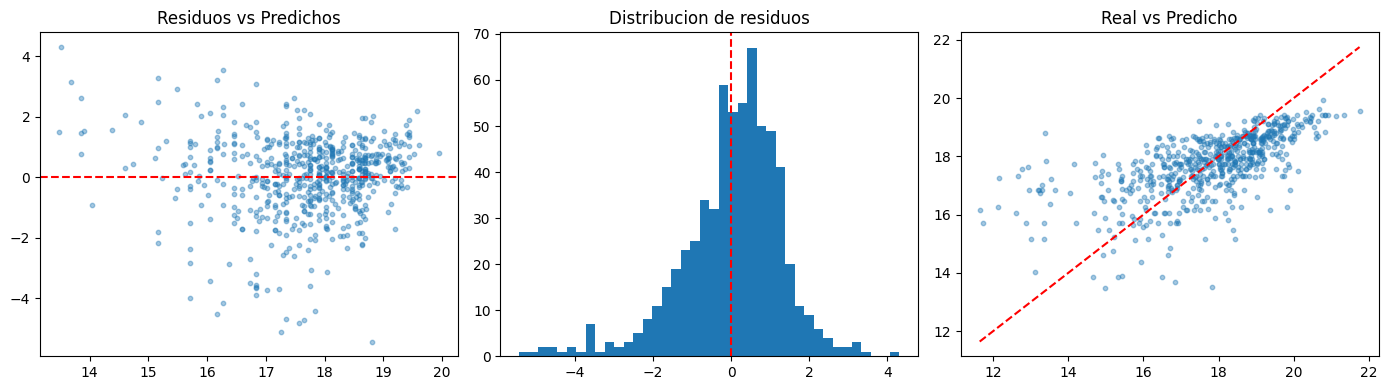

In [21]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_pred, residuos, alpha=0.4, s=10)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title('Residuos vs Predichos')

axes[1].hist(residuos, bins=40)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Distribucion de residuos')

mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[2].scatter(y_test, y_pred, alpha=0.4, s=10)
axes[2].plot([mn, mx], [mn, mx], color='red', ls='--')
axes[2].set_title('Real vs Predicho')

plt.tight_layout()
plt.show()

## Sección 9

Seccion 9 — Regresion multiple
Se anaden mas variables predictoras. Al tener features en escalas muy distintas (log_budget en ~18, runtime en ~100), estandarizar con StandardScaler permite comparar los coeficientes directamente: el mas grande en valor absoluto es el que mas influye.

Pista: ajusta el scaler solo con train (fit_transform) y aplica la transformacion a test (transform). Nunca al reves o habra data leakage.

### Regresion múltiple

In [22]:
from sklearn.preprocessing import StandardScaler

R²:   0.6236
RMSE: 1.0382


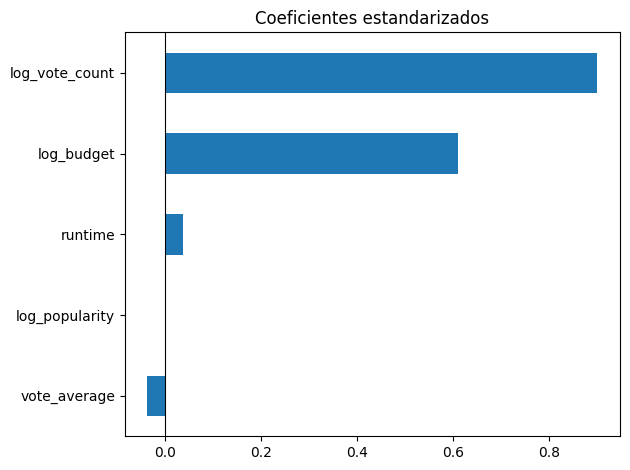

In [23]:
feature_cols = ['log_budget', 'log_popularity', 'log_vote_count', 'vote_average', 'runtime']

X_m = df[feature_cols].fillna(df[feature_cols].median())
y   = df['log_revenue']

X_tr, X_te, y_tr, y_te = train_test_split(X_m, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
modelo_m = LinearRegression().fit(scaler.fit_transform(X_tr), y_tr)
y_pred_m = modelo_m.predict(scaler.transform(X_te))

print(f'R²:   {r2_score(y_te, y_pred_m):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_te, y_pred_m)):.4f}')

# Coeficientes
pd.Series(modelo_m.coef_, index=feature_cols).sort_values().plot(kind='barh')
plt.axvline(0, color='black', lw=0.8)
plt.title('Coeficientes estandarizados')
plt.tight_layout()
plt.show()

## Sección 10

Seccion 10 — Ingenieria de caracteristicas

Se aprovecha la informacion que ya extrajiste del JSON para crear dos nuevas features:

    Dummies de genero: convierte la columna categorica main_genre en columnas binarias (0/1), una por genero. Permite al modelo aprender que genero tiene distinto impacto en revenue.
    
    director_avg_revenue: el promedio historico de log_revenue de cada director en el dataset. Es un proxy de su "poder de taquilla".

Al final compara los tres modelos en una tabla con R² y RMSE.

Pista: para los dummies puedes usar value_counts().head(8).index para obtener los generos mas frecuentes y luego crear una columna por cada uno con una comparacion booleana. Para el promedio del director usa groupby + map.

### Ingenieria de caracteristicas

In [29]:
df['main_genre'].value_counts().head(8).index

Index(['Drama', 'Comedy', 'Action', 'Adventure', 'Horror', 'Crime', 'Thriller',
       'Animation'],
      dtype='str', name='main_genre')

In [31]:
resultado = df.groupby('director')['log_revenue'].mean()
print(resultado)

director
Abel Ferrara        14.020348
Adam Marcus         16.584221
Adam McKay          18.755663
Adam Rapp           11.642057
Adam Rifkin         15.254662
                      ...    
Zach Braff          16.310224
Zack Snyder         19.330526
Zal Batmanglij      14.691609
Zhang Yimou         18.683273
Émile Gaudreault    14.924668
Name: log_revenue, Length: 1393, dtype: float64


In [33]:
top_genres = df['main_genre'].value_counts().head(8).index.tolist()
for g in top_genres:
    df[f'genre_{g}'] = (df['main_genre'] == g).astype(int)

df['director_avg_revenue'] = df['director'].map(
    df.groupby('director')['log_revenue'].mean()
)

genre_cols     = [f'genre_{g}' for g in top_genres]
feature_cols_v2 = feature_cols + genre_cols + ['director_avg_revenue']

X_v2 = df[feature_cols_v2].fillna(df[feature_cols_v2].median())
y_v2 = df['log_revenue']

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

sc2 = StandardScaler()
modelo_v2 = LinearRegression().fit(sc2.fit_transform(X_tr2), y_tr2)
y_pred_v2 = modelo_v2.predict(sc2.transform(X_te2))

print(pd.DataFrame({
    'Modelo': ['Simple', 'Multiple', 'Enriquecido'],
    'R²':     [r2_score(y_test, y_pred), r2_score(y_te, y_pred_m), r2_score(y_te2, y_pred_v2)],
    'RMSE':   [np.sqrt(mean_squared_error(y_test, y_pred)),
               np.sqrt(mean_squared_error(y_te, y_pred_m)),
               np.sqrt(mean_squared_error(y_te2, y_pred_v2))]
}).to_string(index=False))

     Modelo       R²     RMSE
     Simple 0.406177 1.304105
   Multiple 0.623643 1.038208
Enriquecido 0.769819 0.811931


## Sección 11

### Reflexión final

Seccion 11 — Reflexion final

No hay codigo. Responde en la celda markdown del notebook.

Preguntas guia:

    1. Que variable numerica tiene mayor correlacion con log_revenue y por que tiene sentido?

    log_vote_count porque los votos de la gente influyen mucho, más que incluso log_budget (presupuesto).
    Esto significa que no siempre un presupuesto alto en una película te garantiza el mejor resultado.

    2. Cuanto mejoro el R² del modelo simple al enriquecido?

    Mejoró en 0.36 puntos o 36% mejor. El simple acierta el 40% de las ocasiones (muy bajo) y el enriquecido el 76%.

    3. Que genero tiene el coeficiente positivo mas alto? Coincide con lo que esperarias?

    El de Animation seguido de Adventure, Fantasy y Science Fiction. Es normal, la gente cuando va al cine quiere evadirse y ver historias que pasan en mundos inventados e imaginativos y sobre todo con final feliz.
